In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.cluster import KMeans
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42
DATASET_NAME = "Credit Card"

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


In [ ]:
possible_paths = [
    "/content/sample_data/creditcard.csv",   # Colab
    "/mnt/data/creditcard.csv",              # local sandbox
    "creditcard.csv"                         # current folder
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "creditcard.csv was not found. Upload the dataset and place it in "
        "/content/sample_data/, /mnt/data/, or the current working directory."
    )

df = pd.read_csv(data_path)
print("Loaded from:", data_path)
df.head()


Loaded from: creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
print("Shape:", df.shape)
print(df.info())
print(df["Class"].value_counts())
print(df.isnull().sum().sum())

Shape: (243625, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243625 entries, 0 to 243624
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    243625 non-null  float64
 1   V1      243625 non-null  float64
 2   V2      243625 non-null  float64
 3   V3      243625 non-null  float64
 4   V4      243625 non-null  float64
 5   V5      243625 non-null  float64
 6   V6      243625 non-null  float64
 7   V7      243625 non-null  float64
 8   V8      243625 non-null  float64
 9   V9      243625 non-null  float64
 10  V10     243625 non-null  float64
 11  V11     243625 non-null  float64
 12  V12     243625 non-null  float64
 13  V13     243625 non-null  float64
 14  V14     243625 non-null  float64
 15  V15     243625 non-null  float64
 16  V16     243625 non-null  float64
 17  V17     243625 non-null  float64
 18  V18     243625 non-null  float64
 19  V19     243625 non-null  float64
 20  V20     243625 non-null  flo

In [ ]:
total_samples = len(df)
fraud_samples = df["Class"].sum()
normal_samples = total_samples - fraud_samples
fraud_ratio = fraud_samples / total_samples

dataset_summary = pd.DataFrame({
    "Metric": ["Total samples", "Normal transactions", "Fraud transactions", "Fraud ratio"],
    "Value": [total_samples, normal_samples, fraud_samples, fraud_ratio]
})

# Contamination is used by several anomaly detection models.
# We clip it slightly to keep every model numerically stable.
CONTAMINATION = float(np.clip(fraud_ratio, 1e-4, 0.05))

dataset_summary


,Metric,Value
0,Total samples,243625.000000
1,Normal transactions,243183.000000
2,Fraud transactions,442.000000
3,Fraud ratio,0.001814


In [ ]:
dataset_summary.to_csv("creditcard_dataset_summary.csv", index=False)

In [ ]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [ ]:
X_normal = X[y == 0]
X_fraud = X[y == 1]

y_normal = y[y == 0]
y_fraud = y[y == 1]

print("Normal samples:", len(X_normal))
print("Fraud samples:", len(X_fraud))

Normal samples: 243182
Fraud samples: 442


In [ ]:
X_train_normal, X_test_normal = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=RANDOM_STATE
)

X_test = pd.concat([X_test_normal, X_fraud], axis=0)
y_test = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(X_fraud))
])

print("Training set shape:", X_train_normal.shape)
print("Test set shape:", X_test.shape)
print("Fraud in test set:", np.sum(y_test))

Training set shape: (194545, 30)
Test set shape: (49079, 30)
Fraud in test set: 442.0


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

In [ ]:
hyperparams_table = pd.DataFrame([
    {
        "Model": "Isolation Forest",
        "Hyperparameters": "n_estimators=100, contamination=CONTAMINATION, random_state=42"
    },
    {
        "Model": "Tuned Isolation Forest",
        "Hyperparameters": "n_estimators=300, max_samples=0.8, contamination=CONTAMINATION, random_state=42"
    },
    {
        "Model": "One-Class SVM",
        "Hyperparameters": "kernel='rbf', nu=CONTAMINATION, gamma='scale'"
    },
    {
        "Model": "Local Outlier Factor",
        "Hyperparameters": "n_neighbors=35, contamination=CONTAMINATION, novelty=True"
    },
    {
        "Model": "Elliptic Envelope",
        "Hyperparameters": "contamination=CONTAMINATION, random_state=42, support_fraction=0.95"
    },
    {
        "Model": "k-Means",
        "Hyperparameters": "n_clusters=8, contamination=CONTAMINATION, random_state=42"
    },
    {
        "Model": "Autoencoder",
        "Hyperparameters": "encoding_dim=14, epochs=20, batch_size=2048, threshold=quantile(1-CONTAMINATION)"
    }
])

hyperparams_table


,Model,Hyperparameters
0,Isolation Forest,"n_estimators=100, contamination=CONTAMINATION,..."
1,Tuned Isolation Forest,"n_estimators=300, max_samples=0.8, contaminati..."
2,One-Class SVM,"kernel='rbf', nu=CONTAMINATION, gamma='scale'"
3,Local Outlier Factor,"n_neighbors=35, contamination=CONTAMINATION, n..."
4,Elliptic Envelope,"contamination=CONTAMINATION, random_state=42, ..."
5,k-Means,"n_clusters=8, contamination=CONTAMINATION, ran..."
6,Autoencoder,"encoding_dim=14, epochs=20, batch_size=2048, t..."


In [ ]:
hyperparams_table.to_csv("creditcard_hyperparameters.csv", index=False)

In [ ]:
class KMeansAnomalyDetector(BaseEstimator):
    def __init__(self, n_clusters=8, contamination=0.01, random_state=42, n_init=10):
        self.n_clusters = n_clusters
        self.contamination = contamination
        self.random_state = random_state
        self.n_init = n_init

    def fit(self, X, y=None):
        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            n_init=self.n_init
        )
        self.kmeans_.fit(X)
        train_distances = self._distance_to_center(X)
        self.threshold_ = np.quantile(train_distances, 1 - self.contamination)
        return self

    def _distance_to_center(self, X):
        centers = self.kmeans_.cluster_centers_
        labels = self.kmeans_.predict(X)
        return np.linalg.norm(X - centers[labels], axis=1)

    def predict(self, X):
        distances = self._distance_to_center(X)
        return np.where(distances > self.threshold_, -1, 1)

    def decision_function(self, X):
        distances = self._distance_to_center(X)
        return self.threshold_ - distances

    def score_samples(self, X):
        distances = self._distance_to_center(X)
        return -distances


class AutoencoderAnomalyDetector(BaseEstimator):
    def __init__(
        self,
        input_dim=None,
        encoding_dim=14,
        contamination=0.01,
        epochs=20,
        batch_size=2048,
        random_state=42
    ):
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        self.contamination = contamination
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state

    def _build_model(self):
        inputs = Input(shape=(self.input_dim,))
        encoded = Dense(self.encoding_dim, activation="relu")(inputs)
        encoded = Dense(max(self.encoding_dim // 2, 4), activation="relu")(encoded)
        decoded = Dense(self.encoding_dim, activation="relu")(encoded)
        outputs = Dense(self.input_dim, activation="linear")(decoded)

        model = Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer="adam", loss="mse")
        return model

    def fit(self, X, y=None):
        self.input_dim = X.shape[1] if self.input_dim is None else self.input_dim
        self.model_ = self._build_model()

        callback = EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )

        self.history_ = self.model_.fit(
            X,
            X,
            validation_split=0.1,
            epochs=self.epochs,
            batch_size=self.batch_size,
            shuffle=True,
            verbose=0,
            callbacks=[callback]
        )

        train_recon = self.model_.predict(X, verbose=0)
        train_errors = np.mean(np.square(X - train_recon), axis=1)
        self.threshold_ = np.quantile(train_errors, 1 - self.contamination)
        return self

    def _reconstruction_error(self, X):
        recon = self.model_.predict(X, verbose=0)
        return np.mean(np.square(X - recon), axis=1)

    def predict(self, X):
        errors = self._reconstruction_error(X)
        return np.where(errors > self.threshold_, -1, 1)

    def decision_function(self, X):
        errors = self._reconstruction_error(X)
        return self.threshold_ - errors

    def score_samples(self, X):
        errors = self._reconstruction_error(X)
        return -errors


models = {
    "Isolation Forest": IsolationForest(
        n_estimators=100,
        contamination=CONTAMINATION,
        random_state=RANDOM_STATE
    ),

    "Tuned Isolation Forest": IsolationForest(
        n_estimators=300,
        max_samples=0.8,
        contamination=CONTAMINATION,
        random_state=RANDOM_STATE
    ),

    "One-Class SVM": OneClassSVM(
        kernel="rbf",
        nu=CONTAMINATION,
        gamma="scale"
    ),

    "Local Outlier Factor": LocalOutlierFactor(
        n_neighbors=35,
        contamination=CONTAMINATION,
        novelty=True
    ),

    "Elliptic Envelope": EllipticEnvelope(
        contamination=CONTAMINATION,
        random_state=RANDOM_STATE,
        support_fraction=0.95
    ),

    "k-Means": KMeansAnomalyDetector(
        n_clusters=8,
        contamination=CONTAMINATION,
        random_state=RANDOM_STATE
    ),

    "Autoencoder": AutoencoderAnomalyDetector(
        input_dim=X_train_scaled.shape[1],
        encoding_dim=14,
        contamination=CONTAMINATION,
        epochs=20,
        batch_size=2048,
        random_state=RANDOM_STATE
    )
}


In [ ]:
def evaluate_model(model, model_name, X_train, X_test, y_test, dataset_name):
    start_train = time.time()
    model.fit(X_train)
    train_time = time.time() - start_train

    start_test = time.time()
    preds_raw = model.predict(X_test)
    test_time = time.time() - start_test

    preds = np.where(preds_raw == -1, 1, 0)

    # Convert model outputs into anomaly scores:
    # higher score = more anomalous
    if model_name == "Local Outlier Factor" and hasattr(model, "score_samples"):
        anomaly_scores = -model.score_samples(X_test)
    elif hasattr(model, "decision_function"):
        anomaly_scores = -model.decision_function(X_test)
    elif hasattr(model, "score_samples"):
        anomaly_scores = -model.score_samples(X_test)
    else:
        anomaly_scores = preds.astype(float)

    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    roc_auc = roc_auc_score(y_test, anomaly_scores)
    pr_auc = average_precision_score(y_test, anomaly_scores)

    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    return {
        "Dataset": dataset_name,
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    }, preds, anomaly_scores


In [ ]:
results = []
predictions_dict = {}
scores_dict = {}

for model_name, model in models.items():
    result, preds, scores = evaluate_model(
        model=model,
        model_name=model_name,
        X_train=X_train_scaled,
        X_test=X_test_scaled,
        y_test=y_test,
        dataset_name=DATASET_NAME
    )

    results.append(result)
    predictions_dict[model_name] = preds
    scores_dict[model_name] = scores

results_df = pd.DataFrame(results)
results_df

,Dataset,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC,TN,FP,FN,TP,Train Time (s),Test Time (s)
0,Credit Card,Isolation Forest,0.709544,0.386878,0.500732,0.950824,0.510580,48567,70,271,171,1.561834,0.348401
1,Credit Card,Tuned Isolation Forest,0.740964,0.556561,0.635659,0.954091,0.670048,48551,86,196,246,22.631205,1.823850
2,Credit Card,One-Class SVM,0.402039,0.803167,0.535849,0.946343,0.652992,48109,528,87,355,145.615246,9.206314
3,Credit Card,Local Outlier Factor,0.052632,0.009050,0.015444,0.851519,0.057939,48565,72,438,4,264.144495,67.047684
4,Credit Card,Elliptic Envelope,0.800448,0.807692,0.804054,0.955042,0.788085,48548,89,85,357,129.979813,0.079918
5,Credit Card,k-Means,0.652174,0.339367,0.446429,0.959657,0.506531,48557,80,292,150,7.947140,0.020445
6,Credit Card,Autoencoder,0.742537,0.450226,0.560563,0.957989,0.617632,48568,69,243,199,21.439331,2.220806


In [ ]:
results_df.to_csv("creditcard_final_results.csv", index=False)

In [ ]:
results_df.sort_values(by="F1-score", ascending=False)

,Dataset,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC,TN,FP,FN,TP,Train Time (s),Test Time (s)
4,Credit Card,Elliptic Envelope,0.800448,0.807692,0.804054,0.955042,0.788085,48548,89,85,357,129.979813,0.079918
1,Credit Card,Tuned Isolation Forest,0.740964,0.556561,0.635659,0.954091,0.670048,48551,86,196,246,22.631205,1.823850
6,Credit Card,Autoencoder,0.742537,0.450226,0.560563,0.957989,0.617632,48568,69,243,199,21.439331,2.220806
2,Credit Card,One-Class SVM,0.402039,0.803167,0.535849,0.946343,0.652992,48109,528,87,355,145.615246,9.206314
0,Credit Card,Isolation Forest,0.709544,0.386878,0.500732,0.950824,0.510580,48567,70,271,171,1.561834,0.348401
5,Credit Card,k-Means,0.652174,0.339367,0.446429,0.959657,0.506531,48557,80,292,150,7.947140,0.020445
3,Credit Card,Local Outlier Factor,0.052632,0.009050,0.015444,0.851519,0.057939,48565,72,438,4,264.144495,67.047684


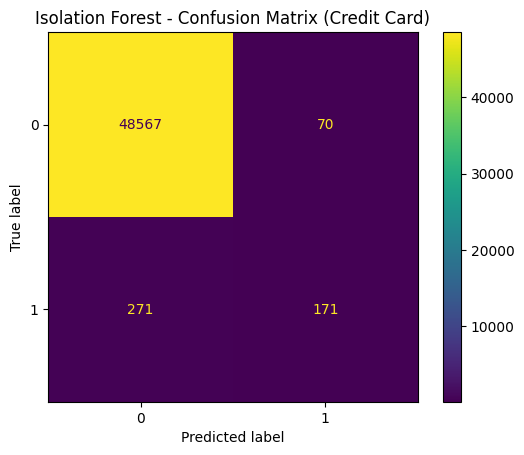

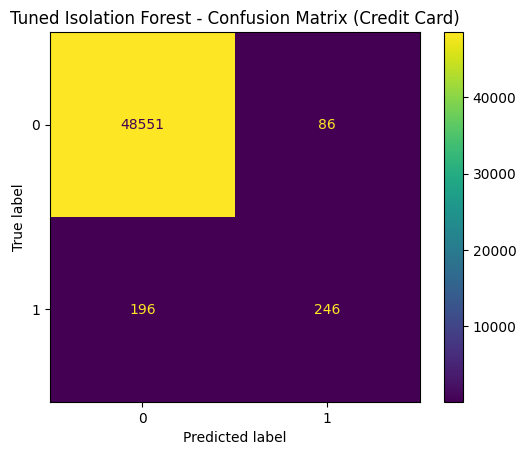

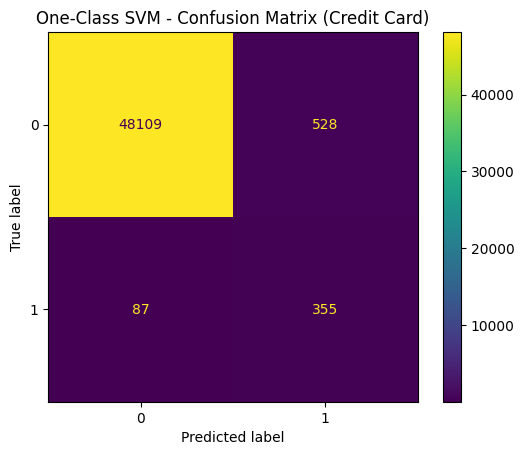

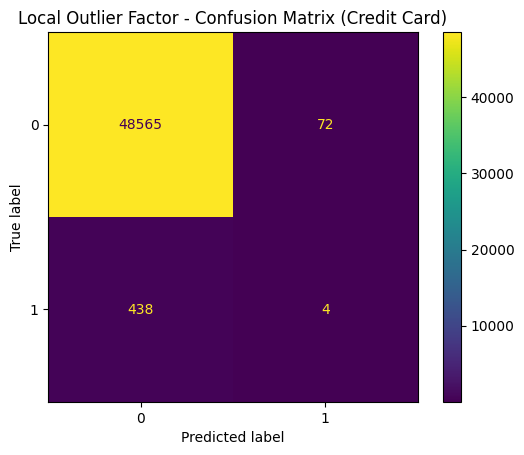

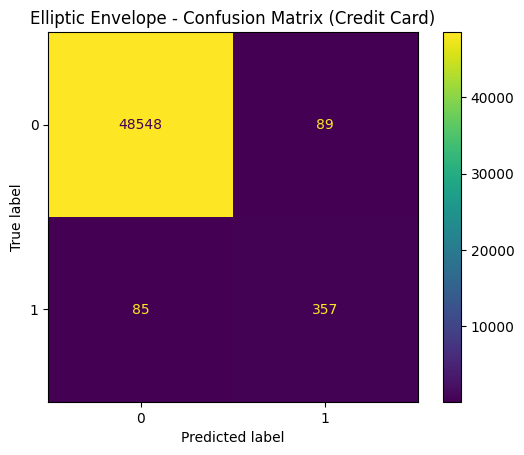

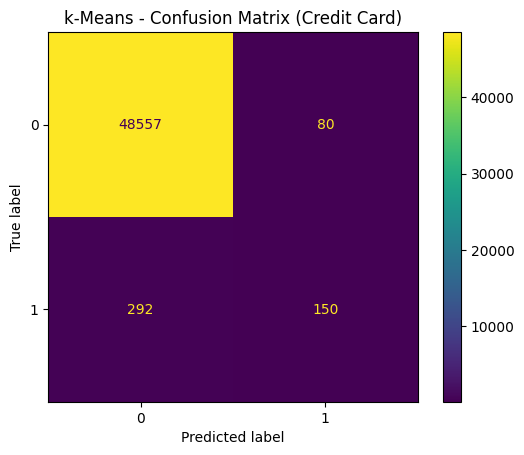

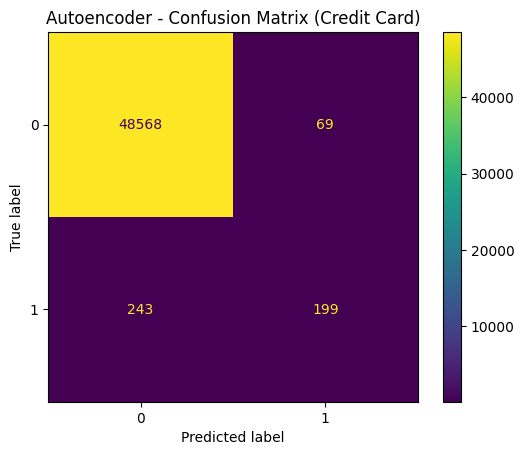

In [ ]:
for model_name in models.keys():
    cm = confusion_matrix(y_test, predictions_dict[model_name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{model_name} - Confusion Matrix ({DATASET_NAME})")
    plt.savefig(f"cm_{model_name.replace(' ', '_').lower()}_creditcard.png", bbox_inches="tight")
    plt.show()

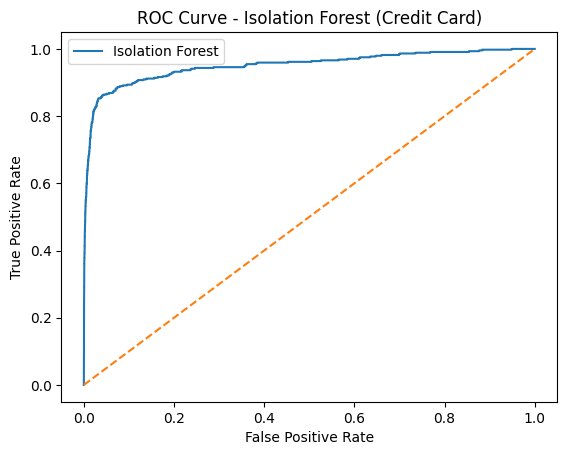

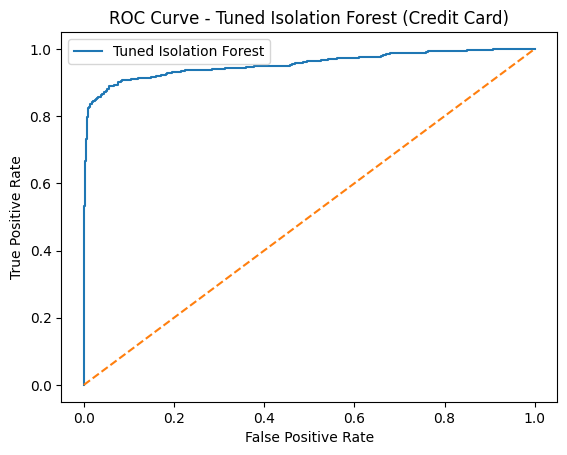

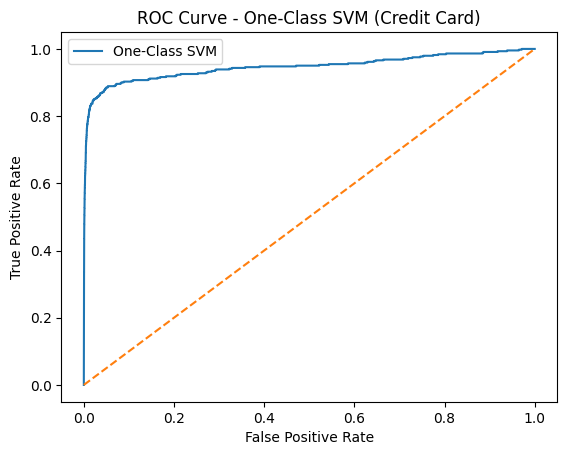

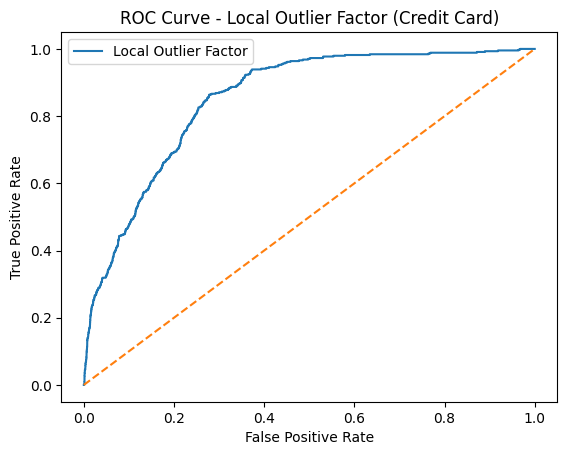

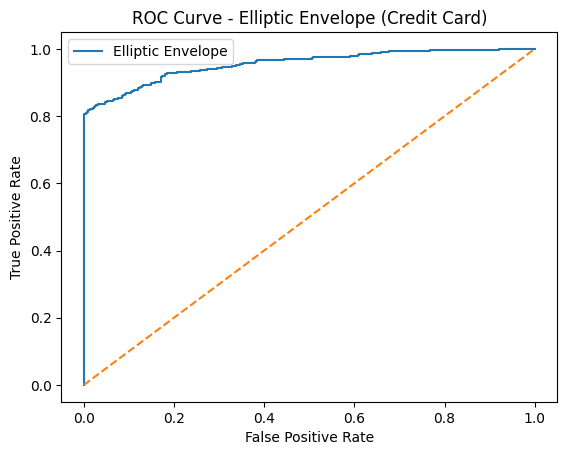

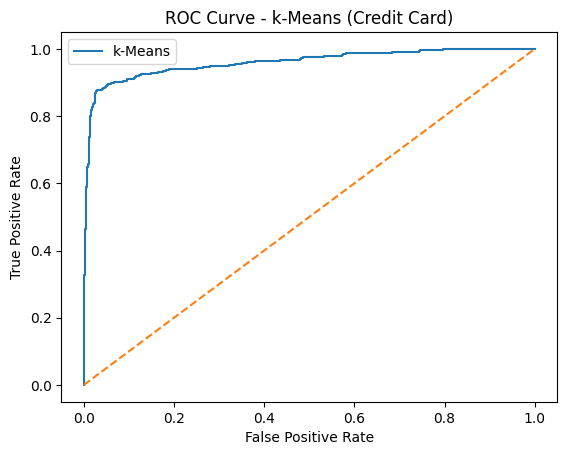

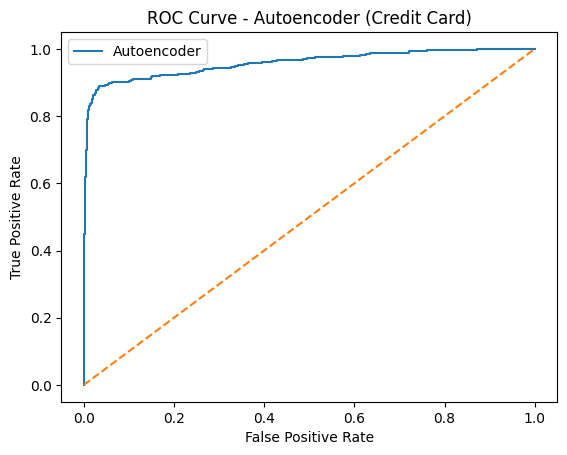

In [ ]:
for model_name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, scores_dict[model_name])
    plt.figure()
    plt.plot(fpr, tpr, label=f"{model_name}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name} ({DATASET_NAME})")
    plt.legend()
    plt.savefig(f"roc_{model_name.replace(' ', '_').lower()}_creditcard.png", bbox_inches="tight")
    plt.show()

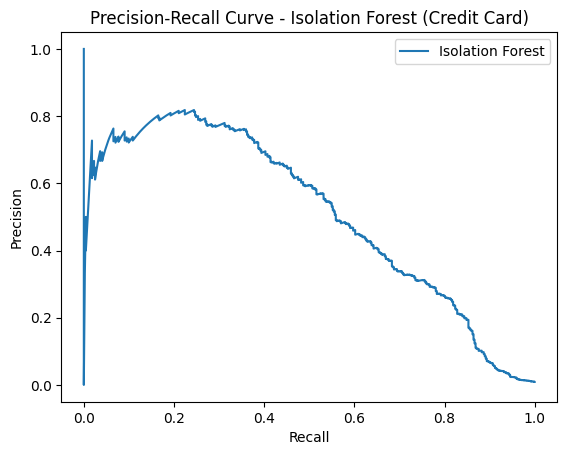

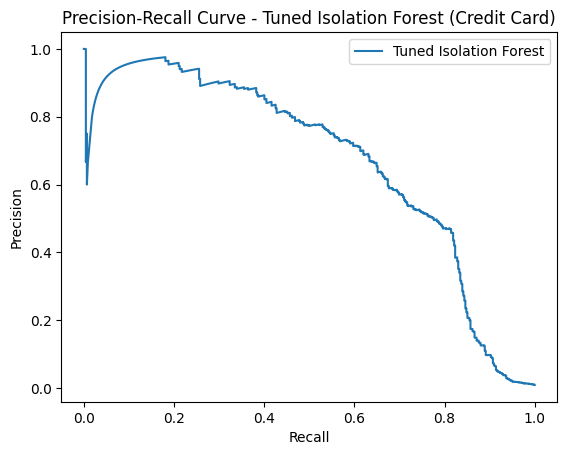

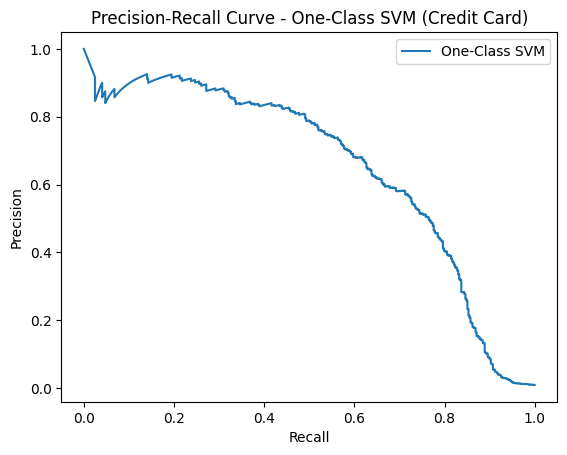

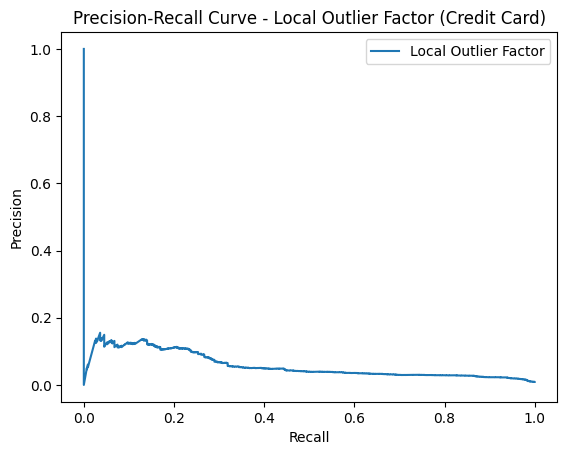

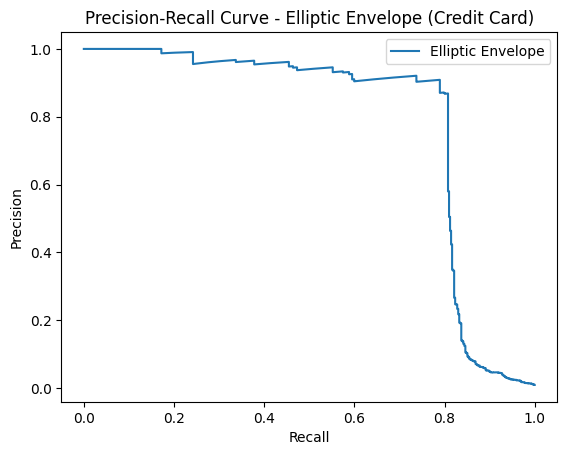

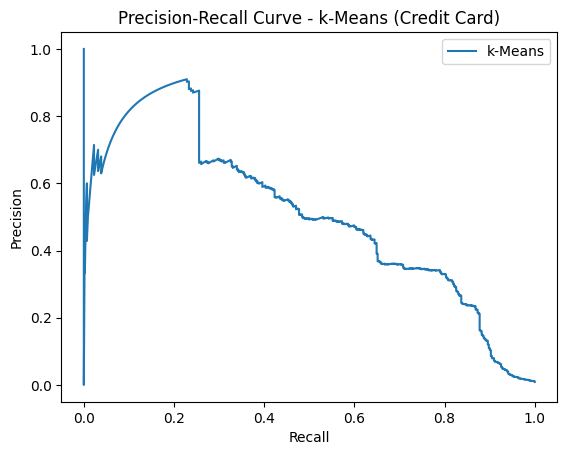

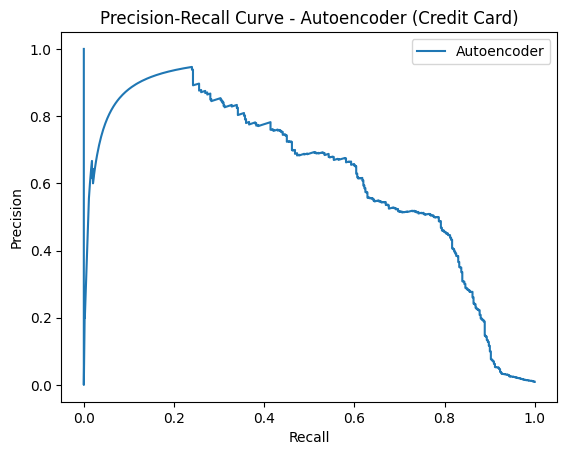

In [ ]:
for model_name in models.keys():
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, scores_dict[model_name])
    plt.figure()
    plt.plot(recall_vals, precision_vals, label=f"{model_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {model_name} ({DATASET_NAME})")
    plt.legend()
    plt.savefig(f"pr_{model_name.replace(' ', '_').lower()}_creditcard.png", bbox_inches="tight")
    plt.show()

In [ ]:
best_model_row = results_df.sort_values(by="F1-score", ascending=False).iloc[0]
best_model_row

,4
Dataset,Credit Card
Model,Elliptic Envelope
Precision,0.800448
Recall,0.807692
F1-score,0.804054
ROC-AUC,0.955042
PR-AUC,0.788085
TN,48548
FP,89
FN,85


In [ ]:
comparison_df = results_df[[
    "Model",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "PR-AUC"
]].copy()

# сортируем по F1 (главная метрика)
comparison_df = comparison_df.sort_values(by="F1-score", ascending=False)

comparison_df

,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC
4,Elliptic Envelope,0.800448,0.807692,0.804054,0.955042,0.788085
1,Tuned Isolation Forest,0.740964,0.556561,0.635659,0.954091,0.670048
6,Autoencoder,0.742537,0.450226,0.560563,0.957989,0.617632
2,One-Class SVM,0.402039,0.803167,0.535849,0.946343,0.652992
0,Isolation Forest,0.709544,0.386878,0.500732,0.950824,0.510580
5,k-Means,0.652174,0.339367,0.446429,0.959657,0.506531
3,Local Outlier Factor,0.052632,0.009050,0.015444,0.851519,0.057939
